In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential

2026-05-01 02:55:24.356753: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Data Generation: Sine Curves

Generate **10,000 sine curves** of the form:

$$
x(t) = A \cdot \sin(\omega t + \phi)
$$

where the parameters are drawn from uniform distributions:

- Amplitude: $ A \sim \mathcal{U}[0.5, 1.5] $
- Frequency: $ \omega \sim \mathcal{U}[0.5, 2] $
- Phase: $ \phi \sim \mathcal{U}[0, 2\pi] $

Sample each curve at $N = 100$ equally spaced points over $t \in [0, 4\pi]$.
Your clean_curve array should have shape (10000, 100).

In [2]:
# generate dataset
num_curve=10000
A = np.random.uniform(0.5,1.5,size=(num_curve,1))
w = np.random.uniform(0.5,2,size=(num_curve,1))
phi = np.random.uniform(0,2*np.pi,size=(num_curve,1))

N = 100
t = np.linspace(0,4*np.pi,100)

clean_curve = A*np.sin(w*t + phi)
clean_curve.shape

(10000, 100)

## Add Gaussian Noise

$$
x_{\text{noisy}}(t) = x(t) + \epsilon, \qquad \epsilon \sim \mathcal{N}(0, \sigma^2), \quad \sigma = 0.2
$$
Your noisy_curve array should have shape (10000, 100).

In [3]:
# generate noisy data
sigma = 0.2
err = np.random.normal(loc=0, scale=sigma, size=clean_curve.shape)

noisy_curve = clean_curve + err
noisy_curve.shape

(10000, 100)

Plot examples showing the clean and noisy curve.

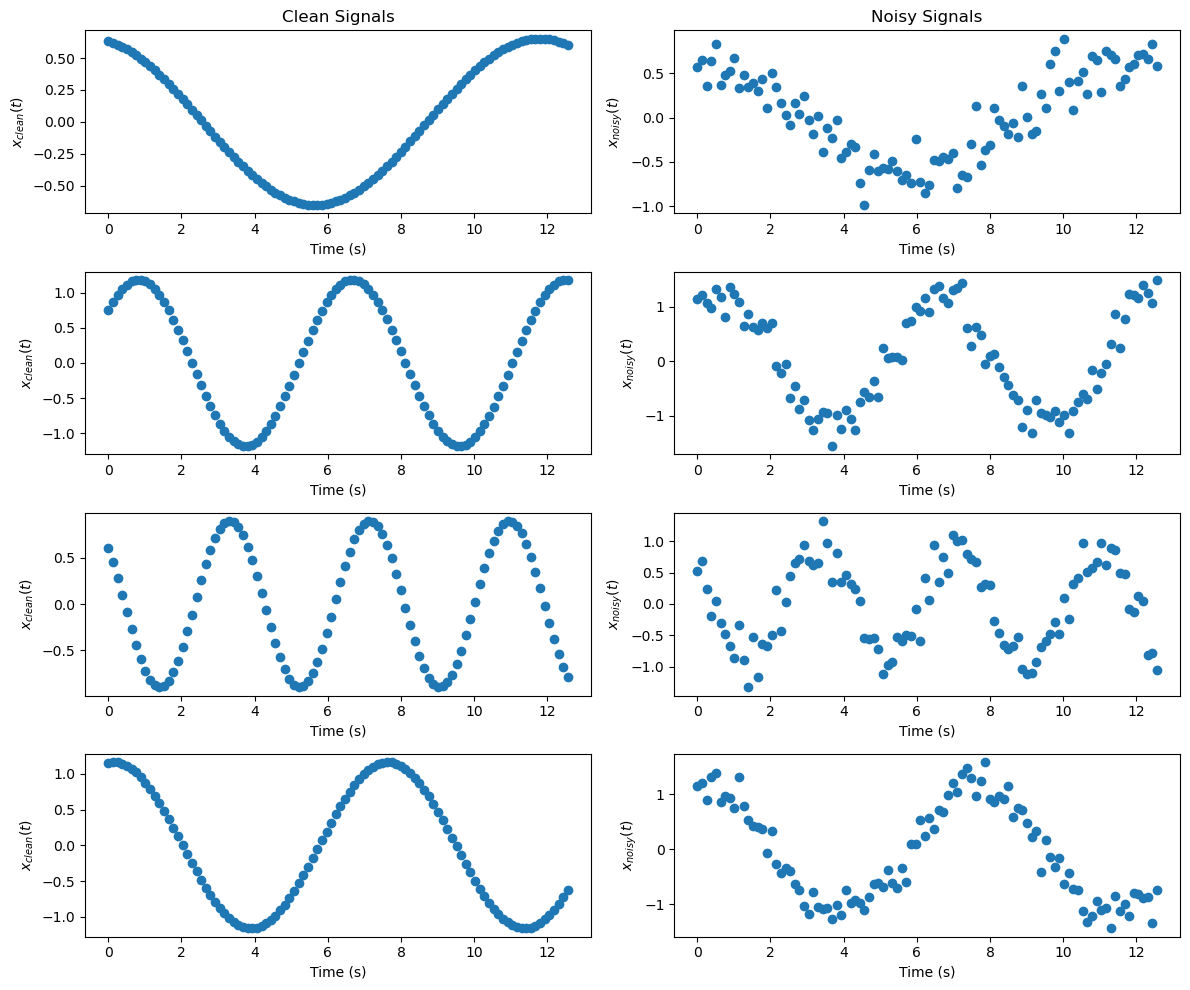

In [4]:
# plot clean vs noisy examples
fig, axes = plt.subplots(4, 2, figsize=(12, 10))
axes[0,0].scatter(t, clean_curve[3])
axes[0,1].scatter(t, noisy_curve[3])

axes[1,0].scatter(t, clean_curve[489])
axes[1,1].scatter(t, noisy_curve[489])

axes[2,0].scatter(t, clean_curve[1864])
axes[2,1].scatter(t, noisy_curve[1864])

axes[3,0].scatter(t, clean_curve[9999])
axes[3,1].scatter(t, noisy_curve[9999])

axes[0,0].set_title("Clean Signals")
axes[0,1].set_title("Noisy Signals")

for i in range(4):
    axes[i,0].set_ylabel(r"$x_{clean}(t)$")
    axes[i,1].set_ylabel(r"$x_{noisy}(t)$")
    
    axes[i,0].set_xlabel("Time (s)")
    axes[i,1].set_xlabel("Time (s)")

plt.tight_layout()
plt.savefig("clean_noisy4.png",dpi=300)
plt.show()

## Dataset Split

Split into **90% training / 10% validation**.
- **Input**  (noisy_curve) : X_train -> shape (9000, 100), X_val -> shape (1000, 100)
- **Target** (clean_curve): Y_train -> shape (9000, 100), Y_val -> shape (1000, 100)

In [5]:
# dataset split
#get a different index for different sine curves
idx = np.random.permutation(num_curve) #this will shuffle through different indices
training_size = int(num_curve*0.9) #90% training - must be integer for indexing
train_idx = idx[:training_size] #the 90% training set
#train_idx.shape
val_idx = idx[training_size:] #the remaning 1000 (10%)
#val_idx.shape

#input
x_train = noisy_curve[train_idx]
x_val = noisy_curve[val_idx]

#target
y_train = clean_curve[train_idx]
y_val = clean_curve[val_idx]

## Autoencoder Model

**Fully connected (dense) autoencoder**
- **Encoder** compresses the input into a low-dimensional **latent space**
- **Decoder** reconstructs the signal from the latent representation

The network is trained to minimise **mean squared error (MSE)** between the reconstructed and clean signal.

In [6]:
autoencoder = Sequential([
    Input(shape=(N,)),
    Dense(64, activation='relu'),
    Dense(16, activation='relu'),  # latent (bottleneck) layer
    Dense(64, activation='relu'),
    Dense(N,  activation='linear') # output layer
])

autoencoder.compile(optimizer=Adam(0.001), loss='mse')
autoencoder.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 100)            │         6,500 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,092 (58.95 KB)

 Trainable params: 15,092 (58.95 KB)

 Non-trainable params: 0 (0.00 B)

## Training with .fit()

.fit() trains the model. The key arguments are:

| Argument | What it means |
|---|---|
| X_train, Y_train | The data the model learns from |
| epochs | How many times the model sees the full training data |
| batch_size | How many samples to process before updating the weights |
| validation_data=(X_val, Y_val) | Data the model never trains on. It is used to check performance after each epoch |
| verbose=1 | Shows a progress bar while training; set to 0 to hide it |

After training, history stores the training loss and validation loss at every epoch:

If validation loss starts increasing while training loss keeps decreasing -> the model is **overfitting** (memorising the training data instead of generalising).

In [7]:
history = autoencoder.fit(
    x_train, y_train,
    epochs=50,
    batch_size=128,
    validation_data=(x_val, y_val),
    verbose=1
)

# extract loss values for plotting
train_loss   = history.history['loss'] # training loss per epoch
val_loss     = history.history['val_loss'] # validation loss per epoch
epochs_range = range(1, len(train_loss) + 1)

Epoch 1/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.3841 - val_loss: 0.1618
Epoch 2/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0730 - val_loss: 0.0392
Epoch 3/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0269 - val_loss: 0.0191
Epoch 4/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0162 - val_loss: 0.0145
Epoch 5/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0127 - val_loss: 0.0120
Epoch 6/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0105 - val_loss: 0.0102
Epoch 7/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0091 - val_loss: 0.0090
Epoch 8/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0082 - val_loss: 0.0083
Epoch 9/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0075 - val_loss: 0.0081
Epoch 10/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0070 - val_loss: 0.0074
Epoch 11/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0066 - val_loss: 0.0068
Epoch 12/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0062 - val_lo

Plot the training and validation loss curves.

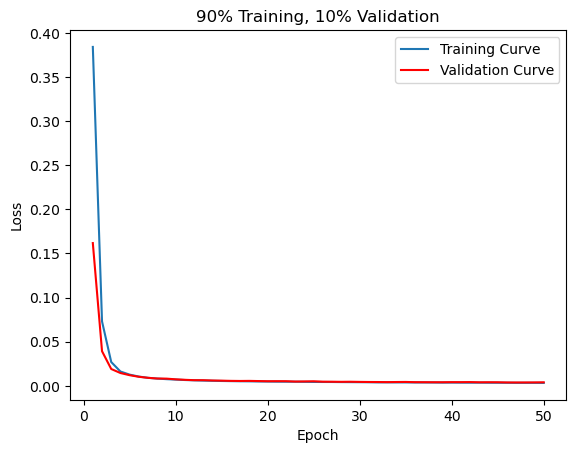

In [8]:
# plot loss curves
plt.plot(epochs_range,train_loss,label="Training Curve")
plt.plot(epochs_range,val_loss, color="red",label="Validation Curve")
plt.title("90% Training, 10% Validation")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend()
plt.savefig("Loss_Curves.png",dpi=300)

## Making Predictions with .predict()

model.predict(X) passes the input array through the trained network and returns reconstructed outputs.

In [9]:
examples = [0, 1, 2, 3]

reconstructed_y = autoencoder.predict(x_val[examples]) # Returns shape (4, 100)
reconstructed_y.shape

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step


(4, 100)

Plot the clean signal, noisy input, and reconstructed signal.

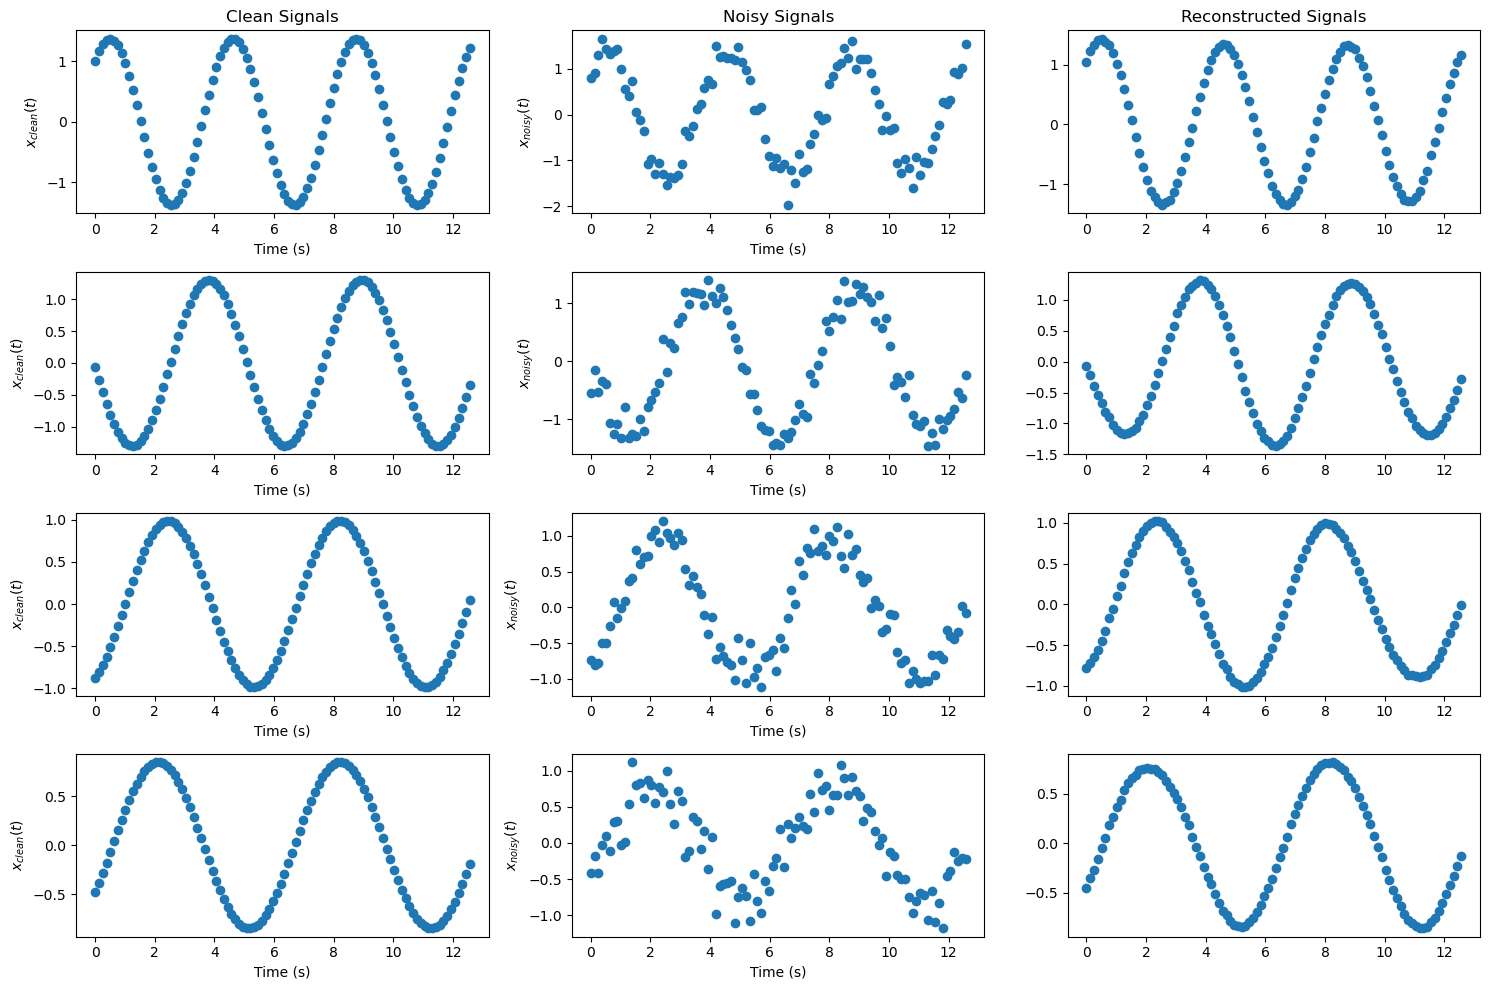

In [10]:
# plot clean vs noisy examples
fig, axes = plt.subplots(4, 3, figsize=(15, 10))
for i, idx in enumerate(examples):
    axes[i,0].scatter(t,y_val[idx]) #clean
    axes[i,1].scatter(t,x_val[idx]) #noisy
    axes[i,2].scatter(t,reconstructed_y[idx]) #reconstructed
axes[0,0].set_title("Clean Signals")
axes[0,1].set_title("Noisy Signals")
axes[0,2].set_title("Reconstructed Signals")

for i in range(4):
    axes[i,0].set_ylabel(r"$x_{clean}(t)$")
    axes[i,1].set_ylabel(r"$x_{noisy}(t)$")
    
    axes[i,0].set_xlabel("Time (s)")
    axes[i,1].set_xlabel("Time (s)")

plt.tight_layout()
plt.savefig("reconstructed.png",dpi=300)
plt.show()

# Parameter Exploration
Investigate how performance changes when modifying the following parameters. For each experiment, provide plots of training and validation loss vs. epochs. Also report the architecture and comment on whether training converges and whether you observe overfitting.

## Training data size 
- 90% training , 10% validation (baseline)
- 60% training , 40% validation
- 30% training , 70% validation
  
Discuss the effect on validation MSE and overfitting.

In [11]:
autoencoder = Sequential([
    Input(shape=(N,)),
    Dense(64, activation='relu'),
    Dense(16, activation='relu'),  # latent (bottleneck) layer
    Dense(64, activation='relu'),
    Dense(N,  activation='linear') # output layer
])

autoencoder.compile(optimizer=Adam(0.001), loss='mse')
autoencoder.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 100)            │         6,500 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,092 (58.95 KB)

 Trainable params: 15,092 (58.95 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# dataset split
#get a different index for different sine curves
idx = np.random.permutation(num_curve) #this will shuffle through different indices
training_size = int(num_curve*0.9) #90% training - must be integer for indexing
train_idx = idx[:training_size] #the 90% training set
#train_idx.shape
val_idx = idx[training_size:] #the remaning 1000 (10%)
#val_idx.shape

#input
x_train = noisy_curve[train_idx]
x_val = noisy_curve[val_idx]

#target
y_train = clean_curve[train_idx]
y_val = clean_curve[val_idx]

In [13]:
history = autoencoder.fit(
    x_train, y_train,
    epochs=50,
    batch_size=128,
    validation_data=(x_val, y_val),
    verbose=1
)

# extract loss values for plotting
train_loss   = history.history['loss'] # training loss per epoch
val_loss     = history.history['val_loss'] # validation loss per epoch
epochs_range = range(1, len(train_loss) + 1)

Epoch 1/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.3758 - val_loss: 0.1454
Epoch 2/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0733 - val_loss: 0.0322
Epoch 3/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0226 - val_loss: 0.0177
Epoch 4/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0157 - val_loss: 0.0147
Epoch 5/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0129 - val_loss: 0.0121
Epoch 6/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0108 - val_loss: 0.0102
Epoch 7/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0093 - val_loss: 0.0090
Epoch 8/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0083 - val_loss: 0.0085
Epoch 9/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0077 - val_loss: 0.0078
Epoch 10/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0072 - val_loss: 0.0072
Epoch 11/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0068 - val_loss: 0.0069
Epoch 12/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0064 - val_lo

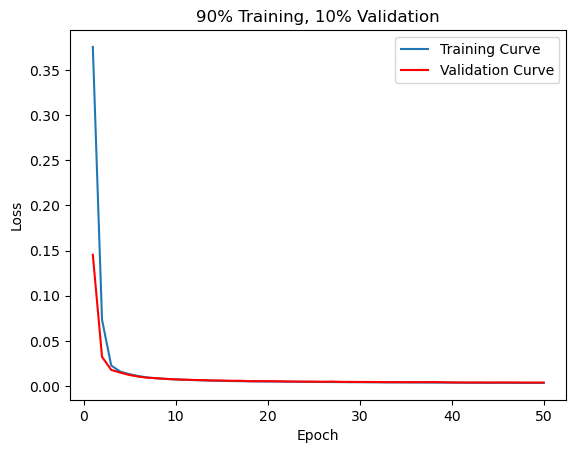

In [14]:
# plot loss curves
plt.plot(epochs_range,train_loss,label="Training Curve")
plt.plot(epochs_range,val_loss, color="red",label="Validation Curve")
plt.title("90% Training, 10% Validation")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend()
plt.savefig("Loss_Curves9010.png",dpi=300)

In [15]:
# dataset split
#get a different index for different sine curves
idx = np.random.permutation(num_curve) #this will shuffle through different indices
training_size = int(num_curve*0.6) #60% training - must be integer for indexing
train_idx = idx[:training_size] #the 60% training set
#train_idx.shape
val_idx = idx[training_size:] #the remaning 1000 (10%)
#val_idx.shape

#input
x_train = noisy_curve[train_idx]
x_val = noisy_curve[val_idx]

#target
y_train = clean_curve[train_idx]
y_val = clean_curve[val_idx]

In [16]:
history = autoencoder.fit(
    x_train, y_train,
    epochs=50,
    batch_size=128,
    validation_data=(x_val, y_val),
    verbose=1
)

# extract loss values for plotting
train_loss   = history.history['loss'] # training loss per epoch
val_loss     = history.history['val_loss'] # validation loss per epoch
epochs_range = range(1, len(train_loss) + 1)

Epoch 1/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0034 - val_loss: 0.0033
Epoch 2/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0033 - val_loss: 0.0035
Epoch 3/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0033 - val_loss: 0.0033
Epoch 4/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0032 - val_loss: 0.0033
Epoch 5/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0033 - val_loss: 0.0033
Epoch 6/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0033 - val_loss: 0.0035
Epoch 7/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0032 - val_loss: 0.0034
Epoch 8/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0032 - val_loss: 0.0036
Epoch 9/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0032 - val_loss: 0.0033
Epoch 10/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0031 - val_loss: 0.0033
Epoch 11/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0031 - val_loss: 0.0033
Epoch 12/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0031 - val_lo

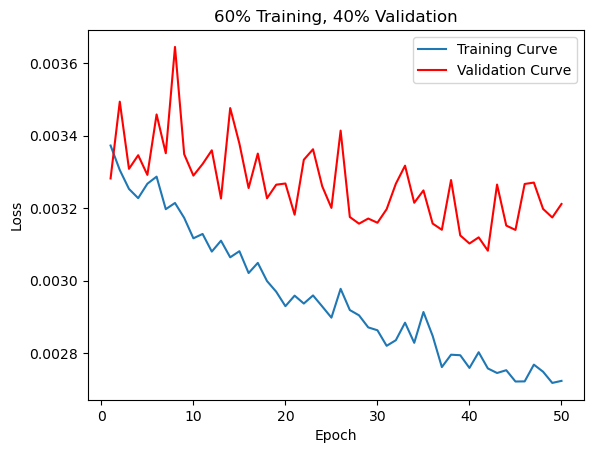

In [17]:
# plot loss curves
plt.plot(epochs_range,train_loss,label="Training Curve")
plt.plot(epochs_range,val_loss, color="red",label="Validation Curve")
plt.title("60% Training, 40% Validation")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend()
plt.savefig("Loss_Curves6040.png",dpi=300)

In [18]:
# dataset split
#get a different index for different sine curves
idx = np.random.permutation(num_curve) #this will shuffle through different indices
training_size = int(num_curve*0.3) #70% training - must be integer for indexing
train_idx = idx[:training_size] #the 90% training set
#train_idx.shape
val_idx = idx[training_size:] #the remaning 1000 (10%)
#val_idx.shape

#input
x_train = noisy_curve[train_idx]
x_val = noisy_curve[val_idx]

#target
y_train = clean_curve[train_idx]
y_val = clean_curve[val_idx]

In [19]:
history = autoencoder.fit(
    x_train, y_train,
    epochs=50,
    batch_size=128,
    validation_data=(x_val, y_val),
    verbose=1
)

# extract loss values for plotting
train_loss   = history.history['loss'] # training loss per epoch
val_loss     = history.history['val_loss'] # validation loss per epoch
epochs_range = range(1, len(train_loss) + 1)

Epoch 1/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0029 - val_loss: 0.0030
Epoch 2/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0028 - val_loss: 0.0030
Epoch 3/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0029 - val_loss: 0.0029
Epoch 4/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0028 - val_loss: 0.0029
Epoch 5/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0028 - val_loss: 0.0029
Epoch 6/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0027 - val_loss: 0.0029
Epoch 7/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0027 - val_loss: 0.0030
Epoch 8/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0027 - val_loss: 0.0029
Epoch 9/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0027 - val_loss: 0.0030
Epoch 10/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0027 - val_loss: 0.0030
Epoch 11/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0027 - val_loss: 0.0029
Epoch 12/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0

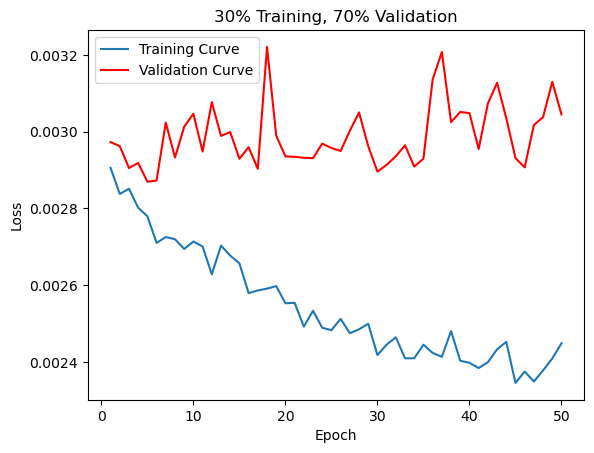

In [20]:
# plot loss curves
plt.plot(epochs_range,train_loss,label="Training Curve")
plt.plot(epochs_range,val_loss, color="red",label="Validation Curve")
plt.title("30% Training, 70% Validation")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend()
plt.savefig("Loss_Curves3070.png",dpi=300)

## Network architecture
Fix the bottleneck at 4 and experiment with different numbers of layers and neurons.

For example:

Model 1 (Baseline): $100 \rightarrow 64 \rightarrow 4 \rightarrow 64 \rightarrow 100$

Model 2 : $100 \rightarrow 80 \rightarrow 40 \rightarrow 4 \rightarrow 40 \rightarrow 80 \rightarrow 100$

Model 3 : $100 \rightarrow 64 \rightarrow 32 \rightarrow 16 \rightarrow 4 \rightarrow 16 \rightarrow 32 \rightarrow 64 \rightarrow 100$

Record the training time and final validation MSE for each architecture.

In [21]:
#Continue using the 90%/10% for this
# dataset split
#get a different index for different sine curves
idx = np.random.permutation(num_curve) #this will shuffle through different indices
training_size = int(num_curve*0.9) #90% training - must be integer for indexing
train_idx = idx[:training_size] #the 90% training set
#train_idx.shape
val_idx = idx[training_size:] #the remaning 1000 (10%)
#val_idx.shape

#input
x_train = noisy_curve[train_idx]
x_val = noisy_curve[val_idx]

#target
y_train = clean_curve[train_idx]
y_val = clean_curve[val_idx]

In [22]:
autoencoder = Sequential([
    Input(shape=(N,)),
    Dense(64, activation='relu'),
    Dense(16, activation='relu'), 
    Dense(4, activation='relu'),  # latent (bottleneck) layer
    Dense(16, activation='relu'),  
    Dense(64, activation='relu'),
    Dense(N,  activation='linear') # output layer
])

autoencoder.compile(optimizer=Adam(0.001), loss='mse')
autoencoder.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 64)             │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 4)              │            68 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 100)            │         6,500 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,240 (59.53 KB)

 Trainable params: 15,240 (59.53 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
start = time.time()
history = autoencoder.fit(
    x_train, y_train,
    epochs=50,
    batch_size=128,
    validation_data=(x_val, y_val),
    verbose=1
)
print(f"Elapsed: {time.time() - start:.4f} seconds")
# extract loss values for plotting
train_loss   = history.history['loss'] # training loss per epoch
val_loss     = history.history['val_loss'] # validation loss per epoch
epochs_range = range(1, len(train_loss) + 1)

Epoch 1/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.4655 - val_loss: 0.3507
Epoch 2/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3045 - val_loss: 0.2336
Epoch 3/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2128 - val_loss: 0.1671
Epoch 4/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1523 - val_loss: 0.1188
Epoch 5/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1108 - val_loss: 0.0911
Epoch 6/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0871 - val_loss: 0.0738
Epoch 7/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0710 - val_loss: 0.0621
Epoch 8/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0590 - val_loss: 0.0526
Epoch 9/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0503 - val_loss: 0.0446
Epoch 10/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0437 - val_loss: 0.0412
Epoch 11/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0390 - val_loss: 0.0369
Epoch 12/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0354 - val_lo

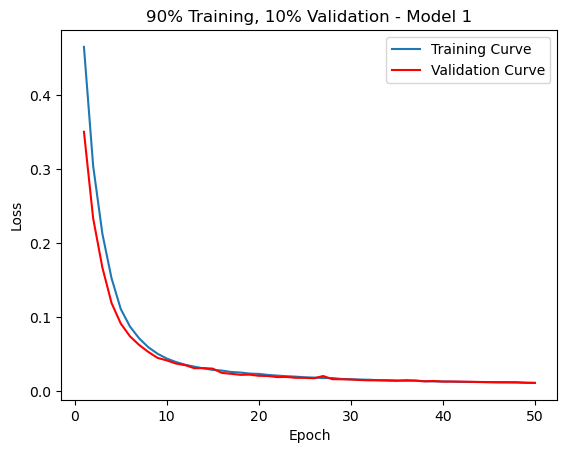

In [24]:
# plot loss curves
plt.plot(epochs_range,train_loss,label="Training Curve")
plt.plot(epochs_range,val_loss, color="red",label="Validation Curve")
plt.title("90% Training, 10% Validation - Model 1")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend()
plt.savefig("Loss_Curves_m1.png",dpi=300)

In [25]:
autoencoder = Sequential([
    Input(shape=(N,)),
    Dense(80, activation='relu'),
    Dense(40, activation='relu'),
    Dense(4, activation='relu'),  # latent (bottleneck) layer
    Dense(40, activation='relu'),
    Dense(80, activation='relu'),
    Dense(N,  activation='linear') # output layer
])

autoencoder.compile(optimizer=Adam(0.001), loss='mse')
autoencoder.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_14 (Dense)                │ (None, 80)             │         8,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 40)             │         3,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 4)              │           164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 40)             │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 80)             │         3,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 100)            │         8,100 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,064 (90.09 KB)

 Trainable params: 23,064 (90.09 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
start = time.time()
history = autoencoder.fit(
    x_train, y_train,
    epochs=50,
    batch_size=128,
    validation_data=(x_val, y_val),
    verbose=1
)
print(f"Elapsed: {time.time() - start:.4f} seconds")
# extract loss values for plotting
train_loss   = history.history['loss'] # training loss per epoch
val_loss     = history.history['val_loss'] # validation loss per epoch
epochs_range = range(1, len(train_loss) + 1)

Epoch 1/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.4313 - val_loss: 0.2676
Epoch 2/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1809 - val_loss: 0.1031
Epoch 3/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0898 - val_loss: 0.0703
Epoch 4/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0616 - val_loss: 0.0508
Epoch 5/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0460 - val_loss: 0.0418
Epoch 6/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0375 - val_loss: 0.0359
Epoch 7/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0319 - val_loss: 0.0315
Epoch 8/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0287 - val_loss: 0.0292
Epoch 9/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0255 - val_loss: 0.0266
Epoch 10/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0227 - val_loss: 0.0254
Epoch 11/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0218 - val_loss: 0.0240
Epoch 12/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0200 - val_lo

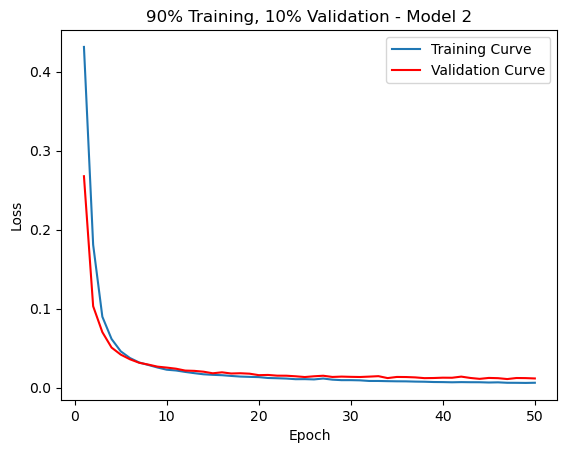

In [27]:
# plot loss curves
plt.plot(epochs_range,train_loss,label="Training Curve")
plt.plot(epochs_range,val_loss, color="red",label="Validation Curve")
plt.title("90% Training, 10% Validation - Model 2")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend()
plt.savefig("Loss_Curves_m2.png",dpi=300)

In [28]:
autoencoder = Sequential([
    Input(shape=(N,)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(4, activation='relu'),  # latent (bottleneck) layer
    Dense(16, activation='relu'),
    Dense(32, activation='relu'),
    Dense(64, activation='relu'),
    Dense(N,  activation='linear') # output layer
])

autoencoder.compile(optimizer=Adam(0.001), loss='mse')
autoencoder.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 64)             │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 4)              │            68 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 100)            │         6,500 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,376 (71.78 KB)

 Trainable params: 18,376 (71.78 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
start = time.time()
history = autoencoder.fit(
    x_train, y_train,
    epochs=50,
    batch_size=128,
    validation_data=(x_val, y_val),
    verbose=1
)
print(f"Elapsed: {time.time() - start:.4f} seconds")
# extract loss values for plotting
train_loss   = history.history['loss'] # training loss per epoch
val_loss     = history.history['val_loss'] # validation loss per epoch
epochs_range = range(1, len(train_loss) + 1)

Epoch 1/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.4465 - val_loss: 0.3216
Epoch 2/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2750 - val_loss: 0.1974
Epoch 3/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1493 - val_loss: 0.1034
Epoch 4/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0877 - val_loss: 0.0740
Epoch 5/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0654 - val_loss: 0.0577
Epoch 6/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0510 - val_loss: 0.0466
Epoch 7/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0416 - val_loss: 0.0408
Epoch 8/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0348 - val_loss: 0.0349
Epoch 9/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0303 - val_loss: 0.0312
Epoch 10/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0271 - val_loss: 0.0288
Epoch 11/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0242 - val_loss: 0.0252
Epoch 12/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0222 - val_lo

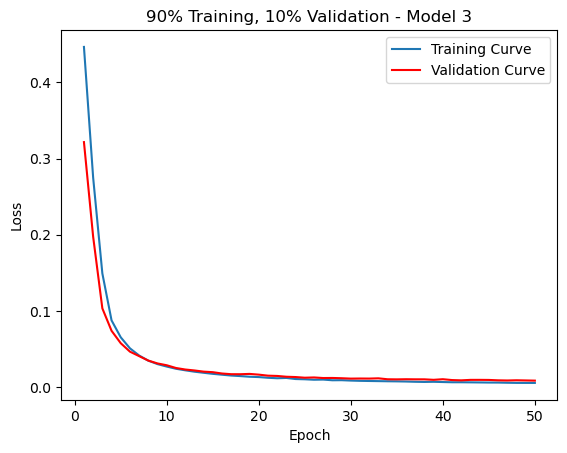

In [30]:
# plot loss curves
plt.plot(epochs_range,train_loss,label="Training Curve")
plt.plot(epochs_range,val_loss, color="red",label="Validation Curve")
plt.title("90% Training, 10% Validation - Model 3")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend()
plt.savefig("Loss_Curves_m3.png",dpi=300)

## Bottleneck Size
Fix the outer architecture (N$ \rightarrow 64 \rightarrow · \rightarrow 64 \rightarrow $N) and vary the bottleneck dimension: 16, 8, 4, 3, 2, 1. Determine the smallest bottleneck size that still reconstructs the signal accurately.

In [31]:
# dataset split
#get a different index for different sine curves
idx = np.random.permutation(num_curve) #this will shuffle through different indices
training_size = int(num_curve*0.9) #90% training - must be integer for indexing
train_idx = idx[:training_size] #the 90% training set
#train_idx.shape
val_idx = idx[training_size:] #the remaning 1000 (10%)
#val_idx.shape

#input
x_train = noisy_curve[train_idx]
x_val = noisy_curve[val_idx]

#target
y_train = clean_curve[train_idx]
y_val = clean_curve[val_idx]

In [32]:
autoencoder = Sequential([
    Input(shape=(N,)),
    Dense(64, activation='relu'),
    Dense(16, activation='relu'),  # latent (bottleneck) layer
    Dense(64, activation='relu'),
    Dense(N,  activation='linear') # output layer
])

autoencoder.compile(optimizer=Adam(0.001), loss='mse')
autoencoder.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_28 (Dense)                │ (None, 64)             │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 100)            │         6,500 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,092 (58.95 KB)

 Trainable params: 15,092 (58.95 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
history = autoencoder.fit(
    x_train, y_train,
    epochs=50,
    batch_size=128,
    validation_data=(x_val, y_val),
    verbose=1
)

# extract loss values for plotting
train_loss   = history.history['loss'] # training loss per epoch
val_loss     = history.history['val_loss'] # validation loss per epoch
epochs_range = range(1, len(train_loss) + 1)

Epoch 1/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.3797 - val_loss: 0.1394
Epoch 2/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0627 - val_loss: 0.0308
Epoch 3/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0224 - val_loss: 0.0178
Epoch 4/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0157 - val_loss: 0.0142
Epoch 5/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0131 - val_loss: 0.0121
Epoch 6/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0111 - val_loss: 0.0103
Epoch 7/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0095 - val_loss: 0.0092
Epoch 8/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0083 - val_loss: 0.0084
Epoch 9/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0074 - val_loss: 0.0075
Epoch 10/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0068 - val_loss: 0.0070
Epoch 11/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0064 - val_loss: 0.0064
Epoch 12/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0059 - val_l

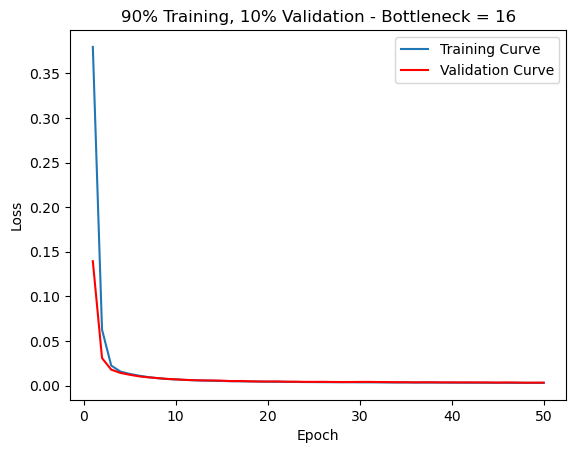

In [34]:
# plot loss curves
plt.plot(epochs_range,train_loss,label="Training Curve")
plt.plot(epochs_range,val_loss, color="red",label="Validation Curve")
plt.title("90% Training, 10% Validation - Bottleneck = 16")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend()
plt.savefig("Loss_Curves_b16.png",dpi=300)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step


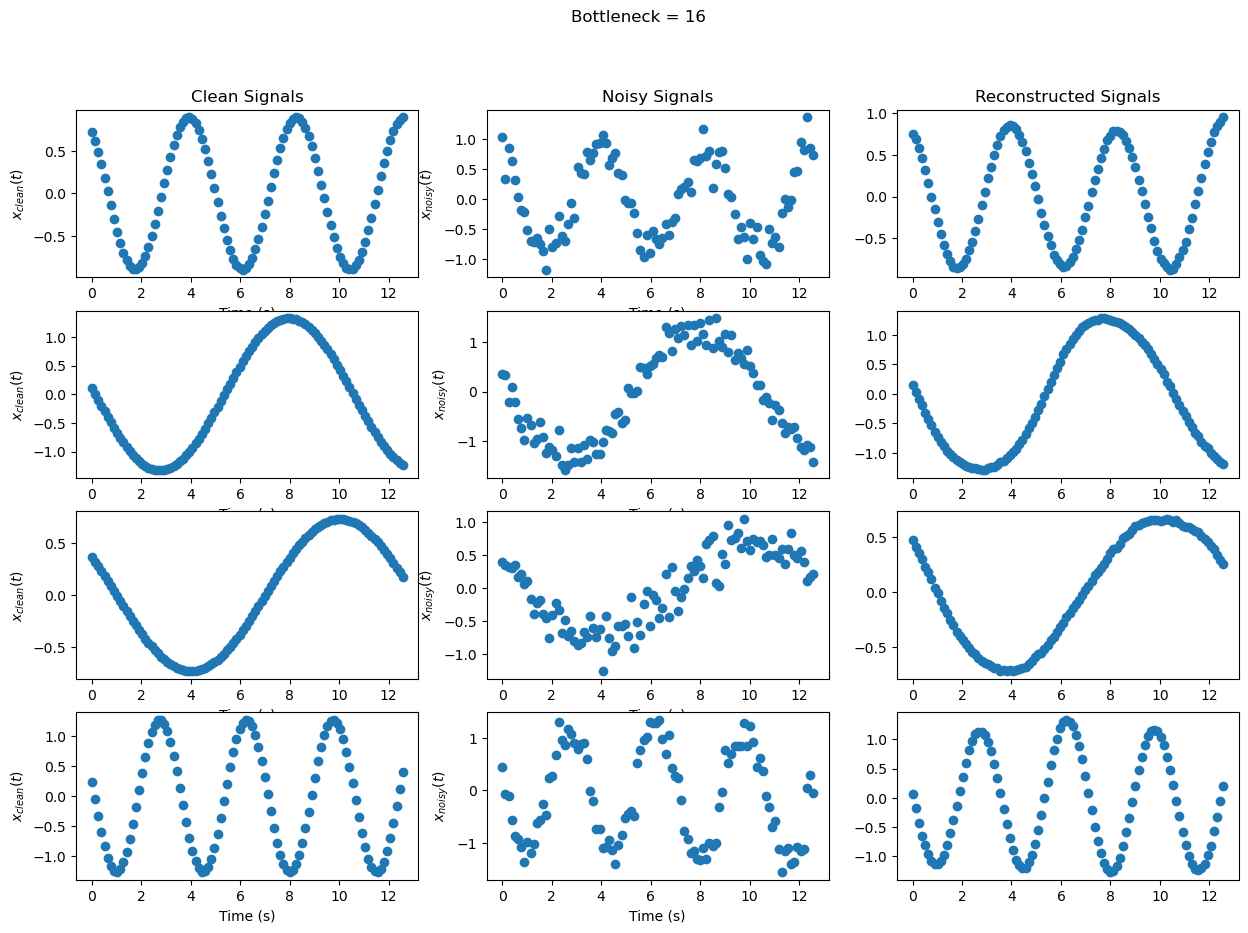

In [35]:
examples = [0, 1, 2, 3]

reconstructed_y = autoencoder.predict(x_val[examples]) # Returns shape (4, 100)
# plot clean vs noisy examples
fig, axes = plt.subplots(4, 3, figsize=(15, 10))
for i, idx in enumerate(examples):
    axes[i,0].scatter(t,y_val[idx]) #clean
    axes[i,1].scatter(t,x_val[idx]) #noisy
    axes[i,2].scatter(t,reconstructed_y[idx]) #reconstructed
axes[0,0].set_title("Clean Signals")
axes[0,1].set_title("Noisy Signals")
axes[0,2].set_title("Reconstructed Signals")
fig.suptitle('Bottleneck = 16')

for i in range(4):
    axes[i,0].set_ylabel(r"$x_{clean}(t)$")
    axes[i,1].set_ylabel(r"$x_{noisy}(t)$")
    
    axes[i,0].set_xlabel("Time (s)")
    axes[i,1].set_xlabel("Time (s)")

plt.savefig("reconstruct_b16.png",dpi=300)
plt.show()

In [36]:
autoencoder = Sequential([
    Input(shape=(N,)),
    Dense(64, activation='relu'),
    Dense(8, activation='relu'),  # latent (bottleneck) layer
    Dense(64, activation='relu'),
    Dense(N,  activation='linear') # output layer
])

autoencoder.compile(optimizer=Adam(0.001), loss='mse')
autoencoder.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_32 (Dense)                │ (None, 64)             │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 8)              │           520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 100)            │         6,500 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,060 (54.92 KB)

 Trainable params: 14,060 (54.92 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
history = autoencoder.fit(
    x_train, y_train,
    epochs=50,
    batch_size=128,
    validation_data=(x_val, y_val),
    verbose=1
)

# extract loss values for plotting
train_loss   = history.history['loss'] # training loss per epoch
val_loss     = history.history['val_loss'] # validation loss per epoch
epochs_range = range(1, len(train_loss) + 1)

Epoch 1/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.4043 - val_loss: 0.2221
Epoch 2/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1149 - val_loss: 0.0605
Epoch 3/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0491 - val_loss: 0.0381
Epoch 4/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0315 - val_loss: 0.0247
Epoch 5/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0203 - val_loss: 0.0165
Epoch 6/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0155 - val_loss: 0.0146
Epoch 7/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0137 - val_loss: 0.0132
Epoch 8/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0126 - val_loss: 0.0122
Epoch 9/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0119 - val_loss: 0.0113
Epoch 10/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0111 - val_loss: 0.0106
Epoch 11/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0105 - val_loss: 0.0101
Epoch 12/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0100 - val_lo

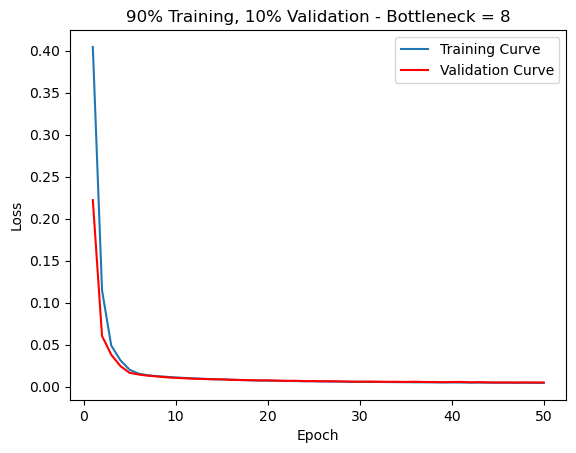

In [38]:
# plot loss curves
plt.plot(epochs_range,train_loss,label="Training Curve")
plt.plot(epochs_range,val_loss, color="red",label="Validation Curve")
plt.title("90% Training, 10% Validation - Bottleneck = 8")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend()
plt.savefig("Loss_Curves_b8.png",dpi=300)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step


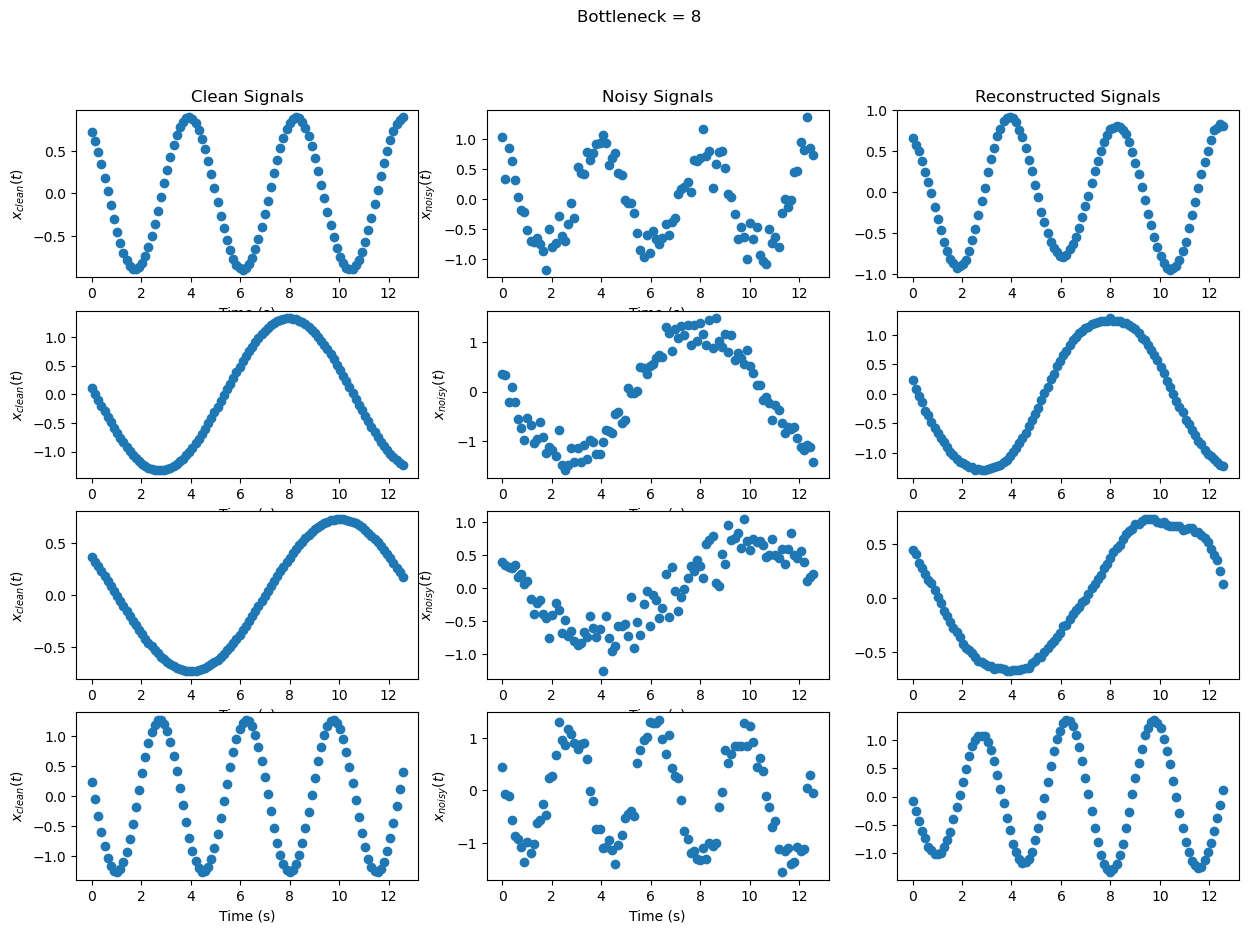

In [39]:
examples = [0, 1, 2, 3]

reconstructed_y = autoencoder.predict(x_val[examples]) # Returns shape (4, 100)
# plot clean vs noisy examples
fig, axes = plt.subplots(4, 3, figsize=(15, 10))
for i, idx in enumerate(examples):
    axes[i,0].scatter(t,y_val[idx]) #clean
    axes[i,1].scatter(t,x_val[idx]) #noisy
    axes[i,2].scatter(t,reconstructed_y[idx]) #reconstructed
axes[0,0].set_title("Clean Signals")
axes[0,1].set_title("Noisy Signals")
axes[0,2].set_title("Reconstructed Signals")
fig.suptitle('Bottleneck = 8')
for i in range(4):
    axes[i,0].set_ylabel(r"$x_{clean}(t)$")
    axes[i,1].set_ylabel(r"$x_{noisy}(t)$")
    
    axes[i,0].set_xlabel("Time (s)")
    axes[i,1].set_xlabel("Time (s)")

plt.savefig("reconstruct_b8.png",dpi=300)
plt.show()

In [40]:
autoencoder = Sequential([
    Input(shape=(N,)),
    Dense(64, activation='relu'),
    Dense(4, activation='relu'),  # latent (bottleneck) layer
    Dense(64, activation='relu'),
    Dense(N,  activation='linear') # output layer
])

autoencoder.compile(optimizer=Adam(0.001), loss='mse')
autoencoder.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_36 (Dense)                │ (None, 64)             │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 4)              │           260 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 100)            │         6,500 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,544 (52.91 KB)

 Trainable params: 13,544 (52.91 KB)

 Non-trainable params: 0 (0.00 B)

In [41]:
history = autoencoder.fit(
    x_train, y_train,
    epochs=50,
    batch_size=128,
    validation_data=(x_val, y_val),
    verbose=1
)

# extract loss values for plotting
train_loss   = history.history['loss'] # training loss per epoch
val_loss     = history.history['val_loss'] # validation loss per epoch
epochs_range = range(1, len(train_loss) + 1)

Epoch 1/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.4354 - val_loss: 0.2821
Epoch 2/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2321 - val_loss: 0.1973
Epoch 3/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1914 - val_loss: 0.1724
Epoch 4/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1668 - val_loss: 0.1495
Epoch 5/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1379 - val_loss: 0.1225
Epoch 6/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1110 - val_loss: 0.0999
Epoch 7/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0900 - val_loss: 0.0804
Epoch 8/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0743 - val_loss: 0.0680
Epoch 9/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0635 - val_loss: 0.0594
Epoch 10/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0566 - val_loss: 0.0538
Epoch 11/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0514 - val_loss: 0.0494
Epoch 12/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0478 - val_lo

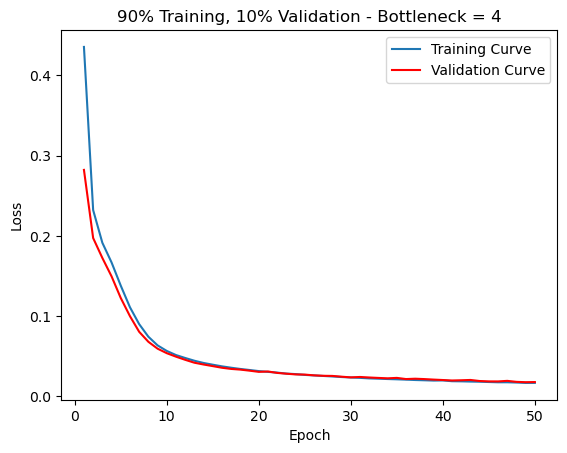

In [42]:
# plot loss curves
plt.plot(epochs_range,train_loss,label="Training Curve")
plt.plot(epochs_range,val_loss, color="red",label="Validation Curve")
plt.title("90% Training, 10% Validation - Bottleneck = 4")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend()
plt.savefig("Loss_Curves_b4.png",dpi=300)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step


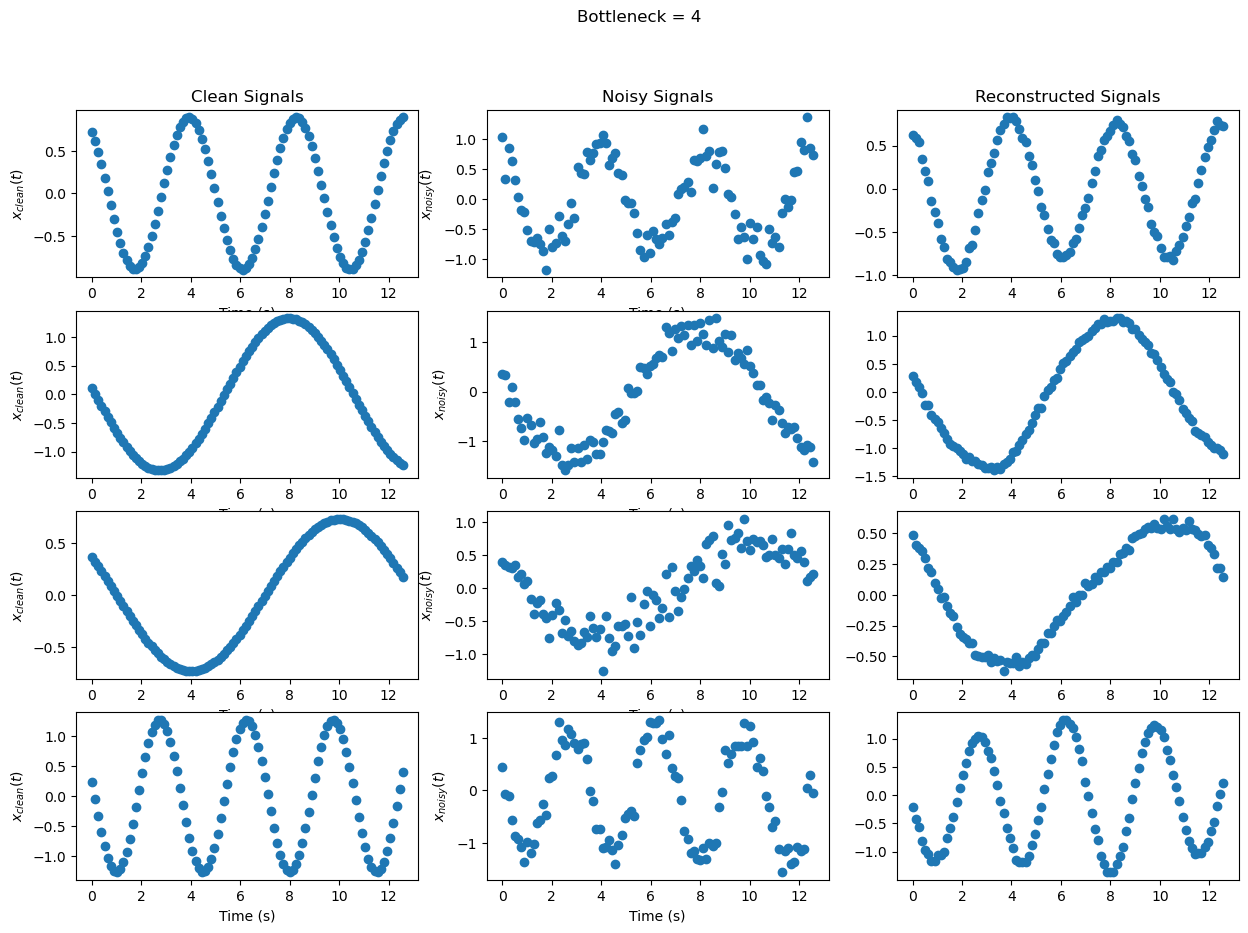

In [43]:
examples = [0, 1, 2, 3]

reconstructed_y = autoencoder.predict(x_val[examples]) # Returns shape (4, 100)
# plot clean vs noisy examples
fig, axes = plt.subplots(4, 3, figsize=(15, 10))
for i, idx in enumerate(examples):
    axes[i,0].scatter(t,y_val[idx]) #clean
    axes[i,1].scatter(t,x_val[idx]) #noisy
    axes[i,2].scatter(t,reconstructed_y[idx]) #reconstructed
axes[0,0].set_title("Clean Signals")
axes[0,1].set_title("Noisy Signals")
axes[0,2].set_title("Reconstructed Signals")
fig.suptitle('Bottleneck = 4')
for i in range(4):
    axes[i,0].set_ylabel(r"$x_{clean}(t)$")
    axes[i,1].set_ylabel(r"$x_{noisy}(t)$")
    
    axes[i,0].set_xlabel("Time (s)")
    axes[i,1].set_xlabel("Time (s)")

plt.savefig("reconstruct_b4.png",dpi=300)
plt.show()

In [44]:
autoencoder = Sequential([
    Input(shape=(N,)),
    Dense(64, activation='relu'),
    Dense(3, activation='relu'),  # latent (bottleneck) layer
    Dense(64, activation='relu'),
    Dense(N,  activation='linear') # output layer
])

autoencoder.compile(optimizer=Adam(0.001), loss='mse')
autoencoder.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_40 (Dense)                │ (None, 64)             │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 3)              │           195 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 100)            │         6,500 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,415 (52.40 KB)

 Trainable params: 13,415 (52.40 KB)

 Non-trainable params: 0 (0.00 B)

In [45]:
history = autoencoder.fit(
    x_train, y_train,
    epochs=50,
    batch_size=128,
    validation_data=(x_val, y_val),
    verbose=1
)

# extract loss values for plotting
train_loss   = history.history['loss'] # training loss per epoch
val_loss     = history.history['val_loss'] # validation loss per epoch
epochs_range = range(1, len(train_loss) + 1)

Epoch 1/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.4562 - val_loss: 0.3623
Epoch 2/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3216 - val_loss: 0.3012
Epoch 3/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2900 - val_loss: 0.2801
Epoch 4/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2695 - val_loss: 0.2537
Epoch 5/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2443 - val_loss: 0.2292
Epoch 6/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2224 - val_loss: 0.2061
Epoch 7/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1985 - val_loss: 0.1864
Epoch 8/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1818 - val_loss: 0.1754
Epoch 9/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1703 - val_loss: 0.1660
Epoch 10/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1606 - val_loss: 0.1553
Epoch 11/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1520 - val_loss: 0.1449
Epoch 12/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1440 - val_lo

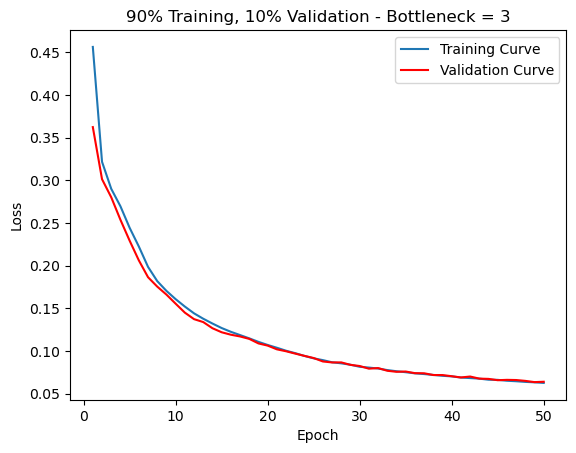

In [46]:
# plot loss curves
plt.plot(epochs_range,train_loss,label="Training Curve")
plt.plot(epochs_range,val_loss, color="red",label="Validation Curve")
plt.title("90% Training, 10% Validation - Bottleneck = 3")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend()
plt.savefig("Loss_Curves_b3.png",dpi=300)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step


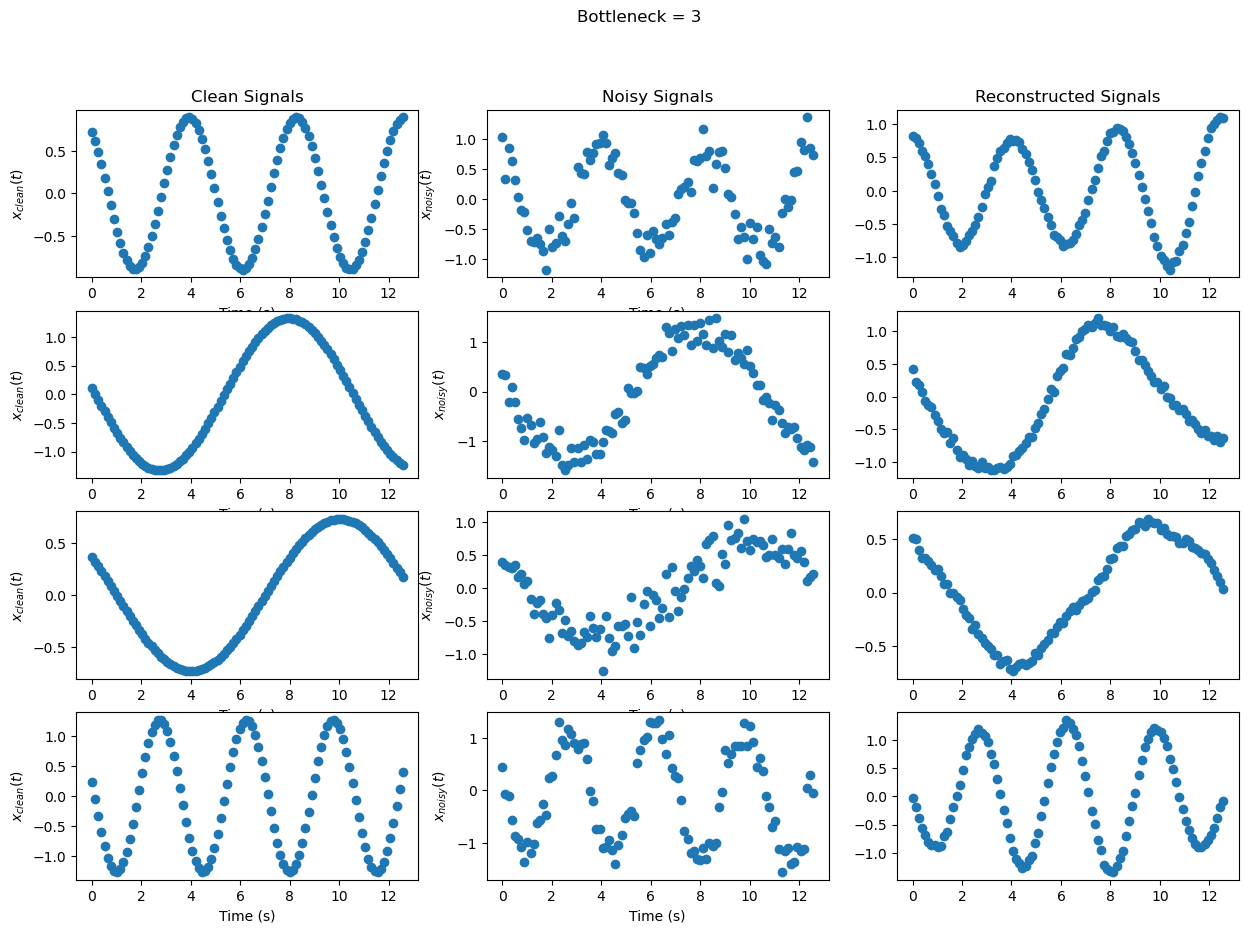

In [47]:
examples = [0, 1, 2, 3]

reconstructed_y = autoencoder.predict(x_val[examples]) # Returns shape (4, 100)
# plot clean vs noisy examples
fig, axes = plt.subplots(4, 3, figsize=(15, 10))
for i, idx in enumerate(examples):
    axes[i,0].scatter(t,y_val[idx]) #clean
    axes[i,1].scatter(t,x_val[idx]) #noisy
    axes[i,2].scatter(t,reconstructed_y[idx]) #reconstructed
axes[0,0].set_title("Clean Signals")
axes[0,1].set_title("Noisy Signals")
axes[0,2].set_title("Reconstructed Signals")
fig.suptitle('Bottleneck = 3')

for i in range(4):
    axes[i,0].set_ylabel(r"$x_{clean}(t)$")
    axes[i,1].set_ylabel(r"$x_{noisy}(t)$")
    
    axes[i,0].set_xlabel("Time (s)")
    axes[i,1].set_xlabel("Time (s)")

plt.savefig("reconstruct_b3.png",dpi=300)
plt.show()

In [48]:
autoencoder = Sequential([
    Input(shape=(N,)),
    Dense(64, activation='relu'),
    Dense(2, activation='relu'),  # latent (bottleneck) layer
    Dense(64, activation='relu'),
    Dense(N,  activation='linear') # output layer
])

autoencoder.compile(optimizer=Adam(0.001), loss='mse')
autoencoder.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_44 (Dense)                │ (None, 64)             │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 2)              │           130 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 64)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 100)            │         6,500 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,286 (51.90 KB)

 Trainable params: 13,286 (51.90 KB)

 Non-trainable params: 0 (0.00 B)

In [49]:
history = autoencoder.fit(
    x_train, y_train,
    epochs=50,
    batch_size=128,
    validation_data=(x_val, y_val),
    verbose=1
)

# extract loss values for plotting
train_loss   = history.history['loss'] # training loss per epoch
val_loss     = history.history['val_loss'] # validation loss per epoch
epochs_range = range(1, len(train_loss) + 1)

Epoch 1/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.4736 - val_loss: 0.4163
Epoch 2/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3881 - val_loss: 0.3734
Epoch 3/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3638 - val_loss: 0.3582
Epoch 4/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3472 - val_loss: 0.3450
Epoch 5/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3344 - val_loss: 0.3337
Epoch 6/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3241 - val_loss: 0.3223
Epoch 7/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3152 - val_loss: 0.3144
Epoch 8/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3080 - val_loss: 0.3068
Epoch 9/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3014 - val_loss: 0.3039
Epoch 10/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2962 - val_loss: 0.2930
Epoch 11/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2899 - val_loss: 0.2899
Epoch 12/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2852 - val_lo

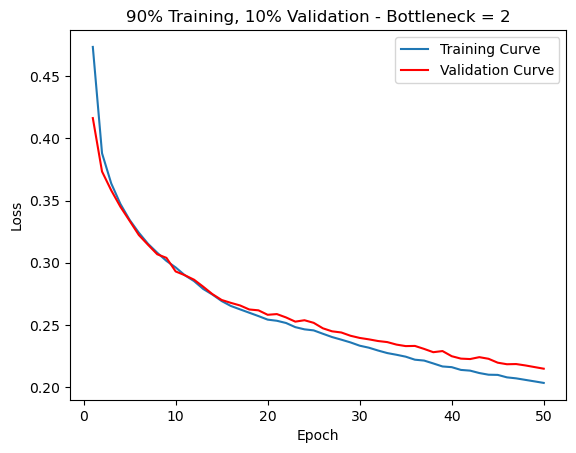

In [50]:
# plot loss curves
plt.plot(epochs_range,train_loss,label="Training Curve")
plt.plot(epochs_range,val_loss, color="red",label="Validation Curve")
plt.title("90% Training, 10% Validation - Bottleneck = 2")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend()
plt.savefig("Loss_Curves_b2.png",dpi=300)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step


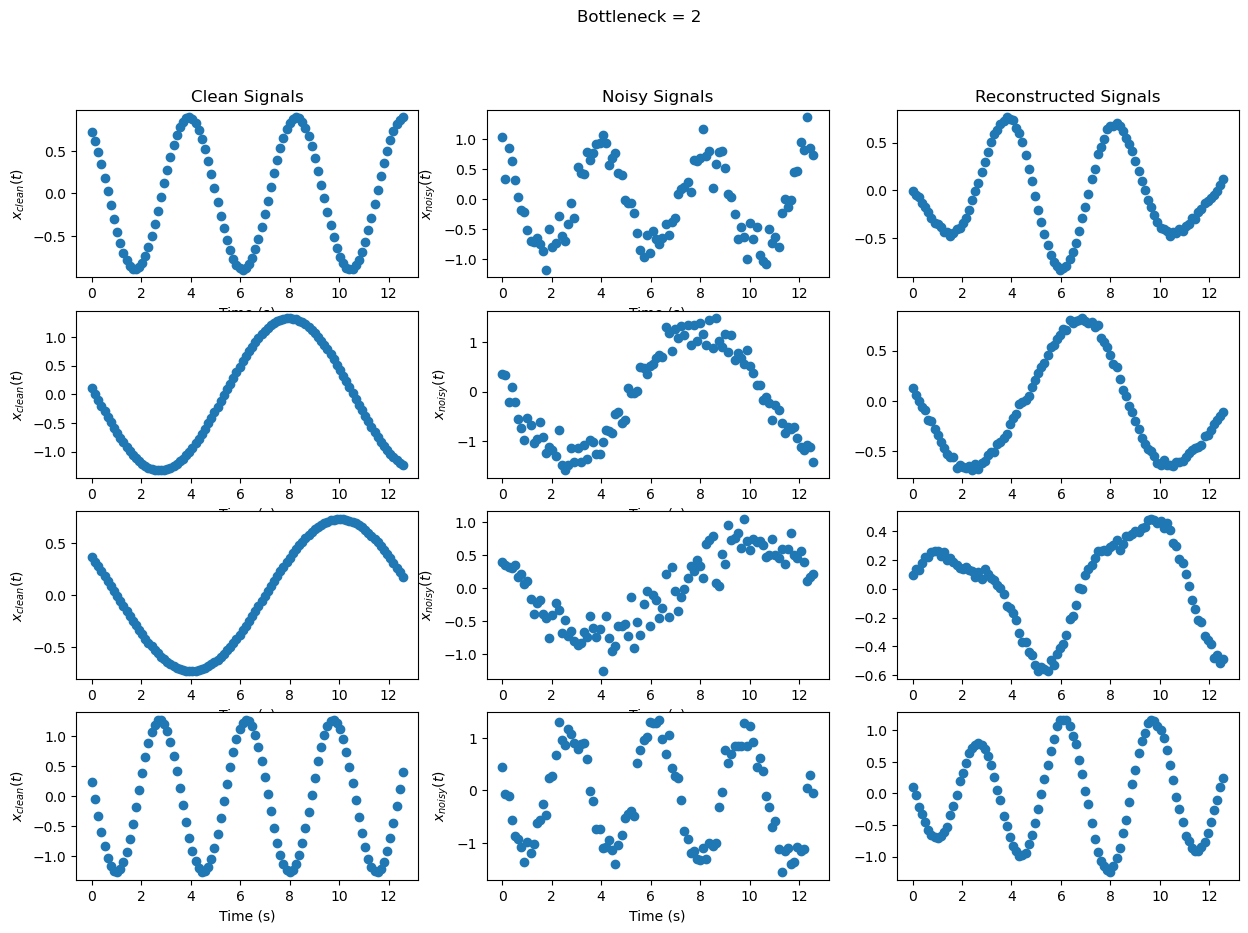

In [51]:
examples = [0, 1, 2, 3]

reconstructed_y = autoencoder.predict(x_val[examples]) # Returns shape (4, 100)
# plot clean vs noisy examples
fig, axes = plt.subplots(4, 3, figsize=(15, 10))
for i, idx in enumerate(examples):
    axes[i,0].scatter(t,y_val[idx]) #clean
    axes[i,1].scatter(t,x_val[idx]) #noisy
    axes[i,2].scatter(t,reconstructed_y[idx]) #reconstructed
axes[0,0].set_title("Clean Signals")
axes[0,1].set_title("Noisy Signals")
axes[0,2].set_title("Reconstructed Signals")
fig.suptitle('Bottleneck = 2')
for i in range(4):
    axes[i,0].set_ylabel(r"$x_{clean}(t)$")
    axes[i,1].set_ylabel(r"$x_{noisy}(t)$")
    
    axes[i,0].set_xlabel("Time (s)")
    axes[i,1].set_xlabel("Time (s)")

plt.savefig("reconstruct_b2.png",dpi=300)
plt.show()

In [52]:
autoencoder = Sequential([
    Input(shape=(N,)),
    Dense(64, activation='relu'),
    Dense(1, activation='relu'),  # latent (bottleneck) layer
    Dense(64, activation='relu'),
    Dense(N,  activation='linear') # output layer
])

autoencoder.compile(optimizer=Adam(0.001), loss='mse')
autoencoder.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_48 (Dense)                │ (None, 64)             │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 1)              │            65 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 64)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ (None, 100)            │         6,500 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,157 (51.39 KB)

 Trainable params: 13,157 (51.39 KB)

 Non-trainable params: 0 (0.00 B)

In [53]:
history = autoencoder.fit(
    x_train, y_train,
    epochs=50,
    batch_size=128,
    validation_data=(x_val, y_val),
    verbose=1
)

# extract loss values for plotting
train_loss   = history.history['loss'] # training loss per epoch
val_loss     = history.history['val_loss'] # validation loss per epoch
epochs_range = range(1, len(train_loss) + 1)

Epoch 1/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.5082 - val_loss: 0.4964
Epoch 2/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4827 - val_loss: 0.4865
Epoch 3/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4738 - val_loss: 0.4798
Epoch 4/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4661 - val_loss: 0.4707
Epoch 5/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4573 - val_loss: 0.4615
Epoch 6/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4490 - val_loss: 0.4527
Epoch 7/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4435 - val_loss: 0.4501
Epoch 8/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4403 - val_loss: 0.4491
Epoch 9/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4382 - val_loss: 0.4443
Epoch 10/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4364 - val_loss: 0.4437
Epoch 11/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4357 - val_loss: 0.4429
Epoch 12/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4347 - val_lo

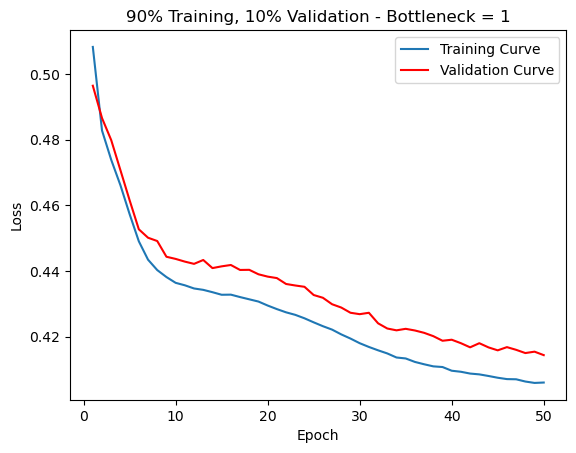

In [54]:
# plot loss curves
plt.plot(epochs_range,train_loss,label="Training Curve")
plt.plot(epochs_range,val_loss, color="red",label="Validation Curve")
plt.title("90% Training, 10% Validation - Bottleneck = 1")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend()
plt.savefig("Loss_Curves_b1.png",dpi=300)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step


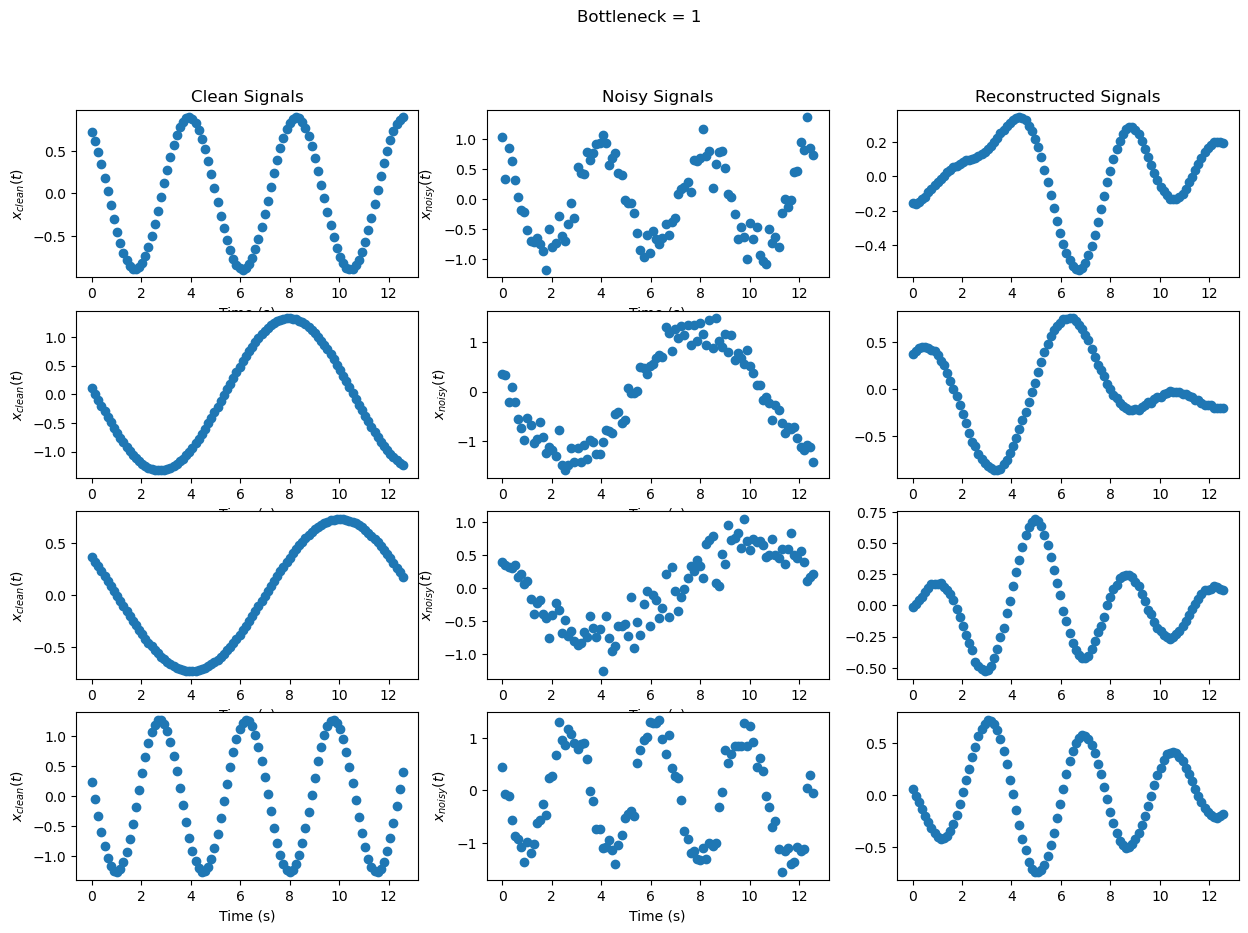

In [55]:
examples = [0, 1, 2, 3]

reconstructed_y = autoencoder.predict(x_val[examples]) # Returns shape (4, 100)
# plot clean vs noisy examples
fig, axes = plt.subplots(4, 3, figsize=(15, 10))
for i, idx in enumerate(examples):
    axes[i,0].scatter(t,y_val[idx]) #clean
    axes[i,1].scatter(t,x_val[idx]) #noisy
    axes[i,2].scatter(t,reconstructed_y[idx]) #reconstructed
axes[0,0].set_title("Clean Signals")
axes[0,1].set_title("Noisy Signals")
axes[0,2].set_title("Reconstructed Signals")
fig.suptitle('Bottleneck = 1')
for i in range(4):
    axes[i,0].set_ylabel(r"$x_{clean}(t)$")
    axes[i,1].set_ylabel(r"$x_{noisy}(t)$")
    
    axes[i,0].set_xlabel("Time (s)")
    axes[i,1].set_xlabel("Time (s)")

plt.savefig("reconstruct_b1.png",dpi=300)
plt.show()

## Noise models
Instead of Gaussian noise, test Laplace noise.

In [56]:
# generate dataset
num_curve=10000
A = np.random.uniform(0.5,1.5,size=(num_curve,1))
w = np.random.uniform(0.5,2,size=(num_curve,1))
phi = np.random.uniform(0,2*np.pi,size=(num_curve,1))

N = 100
t = np.linspace(0,4*np.pi,100)

clean_curve = A*np.sin(w*t + phi)
clean_curve.shape

(10000, 100)

In [57]:
# generate noisy data - Laplace
sigma = 0.2
err = np.random.laplace(loc=0, scale=sigma, size=clean_curve.shape)

noisy_curve = clean_curve + err
noisy_curve.shape

(10000, 100)

In [58]:
# dataset split
#get a different index for different sine curves
idx = np.random.permutation(num_curve) #this will shuffle through different indices
training_size = int(num_curve*0.9) #90% training - must be integer for indexing
train_idx = idx[:training_size] #the 90% training set
#train_idx.shape
val_idx = idx[training_size:] #the remaning 1000 (10%)
#val_idx.shape

#input
x_train = noisy_curve[train_idx]
x_val = noisy_curve[val_idx]

#target
y_train = clean_curve[train_idx]
y_val = clean_curve[val_idx]

In [59]:
autoencoder = Sequential([
    Input(shape=(N,)),
    Dense(64, activation='relu'),
    Dense(16, activation='relu'),  # latent (bottleneck) layer
    Dense(64, activation='relu'),
    Dense(N,  activation='linear') # output layer
])

autoencoder.compile(optimizer=Adam(0.001), loss='mse')
autoencoder.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_52 (Dense)                │ (None, 64)             │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_53 (Dense)                │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_54 (Dense)                │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_55 (Dense)                │ (None, 100)            │         6,500 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,092 (58.95 KB)

 Trainable params: 15,092 (58.95 KB)

 Non-trainable params: 0 (0.00 B)

In [60]:
start = time.time()
history = autoencoder.fit(
    x_train, y_train,
    epochs=50,
    batch_size=128,
    validation_data=(x_val, y_val),
    verbose=1
)
print(f"Elapsed: {time.time() - start:.4f} seconds")
# extract loss values for plotting
train_loss   = history.history['loss'] # training loss per epoch
val_loss     = history.history['val_loss'] # validation loss per epoch
epochs_range = range(1, len(train_loss) + 1)

Epoch 1/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.4013 - val_loss: 0.1708
Epoch 2/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0864 - val_loss: 0.0522
Epoch 3/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0362 - val_loss: 0.0258
Epoch 4/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0216 - val_loss: 0.0195
Epoch 5/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0172 - val_loss: 0.0165
Epoch 6/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0145 - val_loss: 0.0142
Epoch 7/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0127 - val_loss: 0.0125
Epoch 8/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0113 - val_loss: 0.0114
Epoch 9/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0103 - val_loss: 0.0110
Epoch 10/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0096 - val_loss: 0.0099
Epoch 11/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0091 - val_loss: 0.0097
Epoch 12/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0087 - val_lo

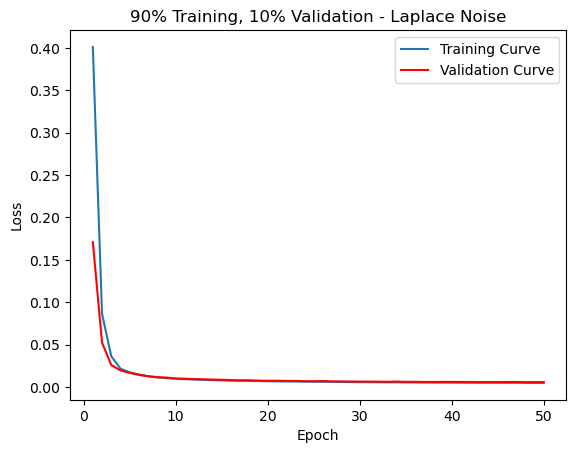

In [61]:
# plot loss curves
plt.plot(epochs_range,train_loss,label="Training Curve")
plt.plot(epochs_range,val_loss, color="red",label="Validation Curve")
plt.title("90% Training, 10% Validation - Laplace Noise")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend()
plt.savefig("Loss_Curves_Laplace.png",dpi=300)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step


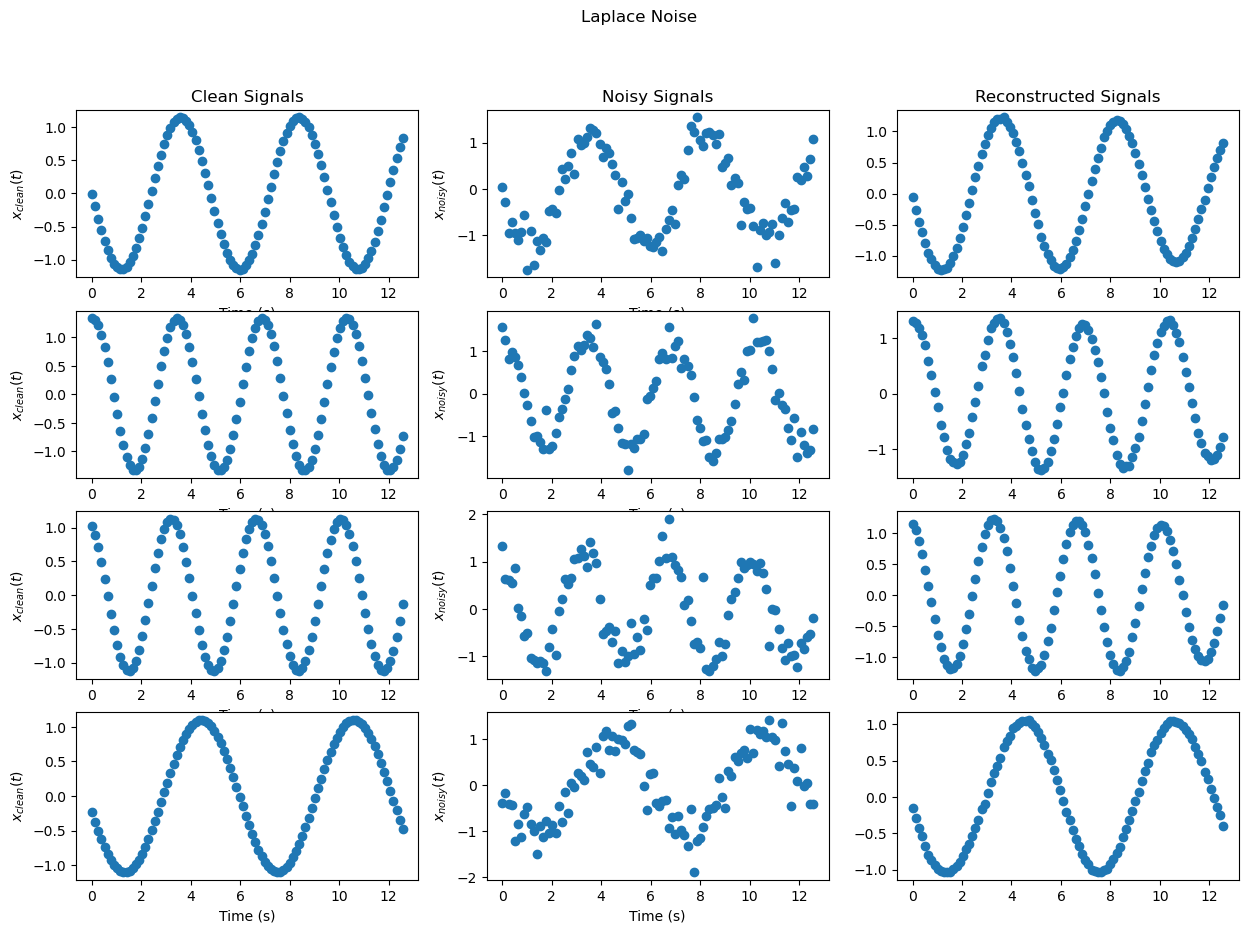

In [62]:
examples = [0, 1, 2, 3]

reconstructed_y = autoencoder.predict(x_val[examples]) # Returns shape (4, 100)

# plot clean vs noisy examples
fig, axes = plt.subplots(4, 3, figsize=(15, 10))
for i, idx in enumerate(examples):
    axes[i,0].scatter(t,y_val[idx]) #clean
    axes[i,1].scatter(t,x_val[idx]) #noisy
    axes[i,2].scatter(t,reconstructed_y[idx]) #reconstructed
axes[0,0].set_title("Clean Signals")
axes[0,1].set_title("Noisy Signals")
axes[0,2].set_title("Reconstructed Signals")
fig.suptitle("Laplace Noise")
for i in range(4):
    axes[i,0].set_ylabel(r"$x_{clean}(t)$")
    axes[i,1].set_ylabel(r"$x_{noisy}(t)$")
    
    axes[i,0].set_xlabel("Time (s)")
    axes[i,1].set_xlabel("Time (s)")

plt.savefig("Reconstruct_Laplace.png",dpi=300)
plt.show()